<a href="https://colab.research.google.com/github/Meerjashaik/ML-LAB-WORK/blob/main/Decision_Tree(Lab_5).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Decision Tree Classification using Machine Learning**
*From Iris Dataset*

# **Aim**

To implement a Decision Tree Classification algorithm using Python and Scikit-learn, train the model on a dataset, evaluate its performance, and visualize the resulting decision tree.

# **Theory**

A Decision Tree is a supervised machine learning algorithm used for both classification and regression tasks. It has a hierarchical structure consisting of a root node, internal nodes, branches, and leaf nodes. Internal nodes represent attribute tests, branches represent attribute values, and leaf nodes represent final predictions.

For classification, the dependent variable is categorical. The leaf node generally represents the mode of the observations falling into that region. Classification and regression trees are collectively called CART.

In this implementation, we use Gini Impurity to determine the best split. Gini impurity is calculated using:

$$ Gini = 1-(p^2+q^2) $$

where p and q represent the probabilities of the two classes. The split having the least Gini impurity is selected.

Decision Trees can suffer from overfitting. Parameters such as maximum depth, minimum samples for splitting, and minimum samples per leaf can be used to control the size of the tree. Pruning is another method used to reduce overfitting.

# **Import Libraries**

In [ ]:
# Import NumPy for numerical operations
import numpy as np

# Import Pandas for handling tabular data
import pandas as pd

# Import Matplotlib for plotting
import matplotlib.pyplot as plt

# Import the Decision Tree Classifier
from sklearn.tree import DecisionTreeClassifier

# Import train_test_split to divide the dataset
from sklearn.model_selection import train_test_split

# Import accuracy_score to evaluate the model
from sklearn.metrics import accuracy_score

# Import functions for visualizing the decision tree
from sklearn.tree import plot_tree

# **Load the Dataset**

In [ ]:
# Import the Iris dataset
from sklearn.datasets import load_iris

# Load the dataset
iris = load_iris()

# Store the input features in X
X = iris.data

# Store the target/output values in y
y = iris.target

# Display the feature names
print("Feature Names:")
print(iris.feature_names)

# Display the target names
print("\nTarget Names:")
print(iris.target_names)

# Display the first five rows
print("\nFirst Five Rows of Dataset:")
print(X[:5])

# Display the first five target values
print("\nFirst Five Target Values:")
print(y[:5])

Feature Names:
['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']

Target Names:
['setosa' 'versicolor' 'virginica']

First Five Rows of Dataset:
[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]]

First Five Target Values:
[0 0 0 0 0]


# **Create a DataFrame**

In [ ]:
# Create a Pandas DataFrame using the feature data
df = pd.DataFrame(X, columns=iris.feature_names)

# Add the target column
df["target"] = y

# Display the first five rows
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


# **Check Dataset Information**

In [ ]:
# Display the number of rows and columns
print("Dataset Shape:")
print(df.shape)

# Display information about the dataset
print("\nDataset Information:")
df.info()

# Check whether there are missing values
print("\nMissing Values:")
print(df.isnull().sum())

Dataset Shape:
(150, 5)

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB

Missing Values:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
target               0
dtype: int64


# **Split the Dataset**

In [ ]:
# Split the dataset into training and testing data
# 80% of the data is used for training
# 20% of the data is used for testing

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Display the size of training and testing data
print("Training data size:", X_train.shape)
print("Testing data size:", X_test.shape)

Training data size: (120, 4)
Testing data size: (30, 4)


# **Create the Decision Tree Model**

In [ ]:
# Create a Decision Tree Classifier
# criterion="gini" means that Gini impurity is used
# max_depth controls the maximum depth of the tree

model = DecisionTreeClassifier(
    criterion="gini",
    max_depth=3,
    random_state=42
)

# Train the Decision Tree model
model.fit(X_train, y_train)

print("Decision Tree model trained successfully.")

Decision Tree model trained successfully.


# **Make Predictions**

In [ ]:
# Predict the classes of the test data
y_pred = model.predict(X_test)

# Display actual and predicted values
print("Actual Values:")
print(y_test)

print("\nPredicted Values:")
print(y_pred)

Actual Values:
[1 0 2 1 1 0 1 2 1 1 2 0 0 0 0 1 2 1 1 2 0 2 0 2 2 2 2 2 0 0]

Predicted Values:
[1 0 2 1 1 0 1 2 1 1 2 0 0 0 0 1 2 1 1 2 0 2 0 2 2 2 2 2 0 0]


# **Calculate Accuracy**

In [ ]:
# Calculate the accuracy of the Decision Tree
accuracy = accuracy_score(y_test, y_pred)

# Display the accuracy
print("Decision Tree Accuracy:", accuracy)
print("Accuracy Percentage:", accuracy * 100, "%")

Decision Tree Accuracy: 1.0
Accuracy Percentage: 100.0 %


# **Visualize the Decision Tree**

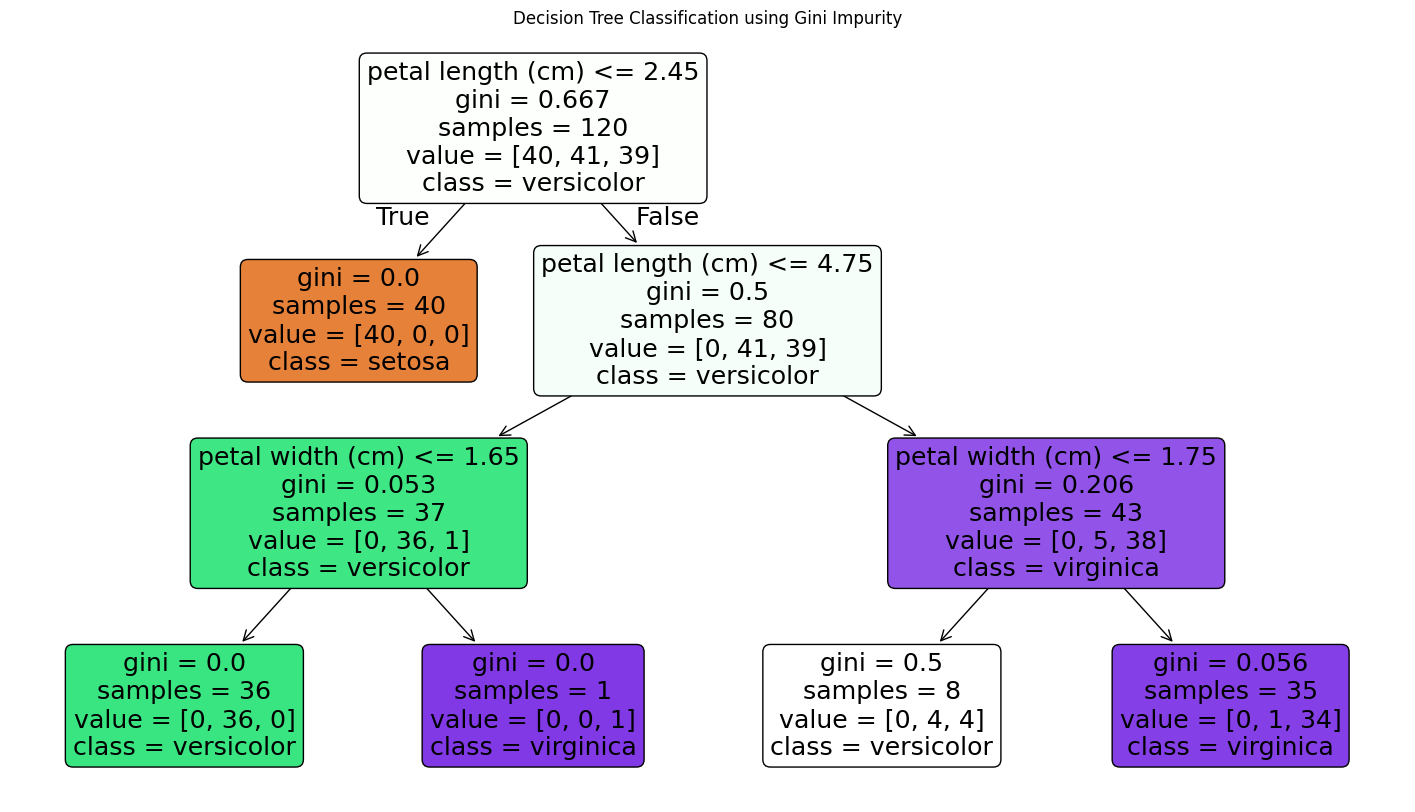

In [ ]:
# Set the size of the figure
plt.figure(figsize=(18, 10))

# Plot the trained decision tree
plot_tree(
    model,
    feature_names=iris.feature_names,
    class_names=iris.target_names,
    filled=True,
    rounded=True
)

# Display the tree
plt.title("Decision Tree Classification using Gini Impurity")
plt.show()

# **Feature Importance**

In [ ]:
# Get the importance of each feature
importance = model.feature_importances_

# Create a DataFrame for better visualization
feature_importance = pd.DataFrame({
    "Feature": iris.feature_names,
    "Importance": importance
})

# Sort features according to importance
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

# Display feature importance
print(feature_importance)

             Feature  Importance
2  petal length (cm)    0.934626
3   petal width (cm)    0.065374
1   sepal width (cm)    0.000000
0  sepal length (cm)    0.000000


# **Plot Feature Importance**

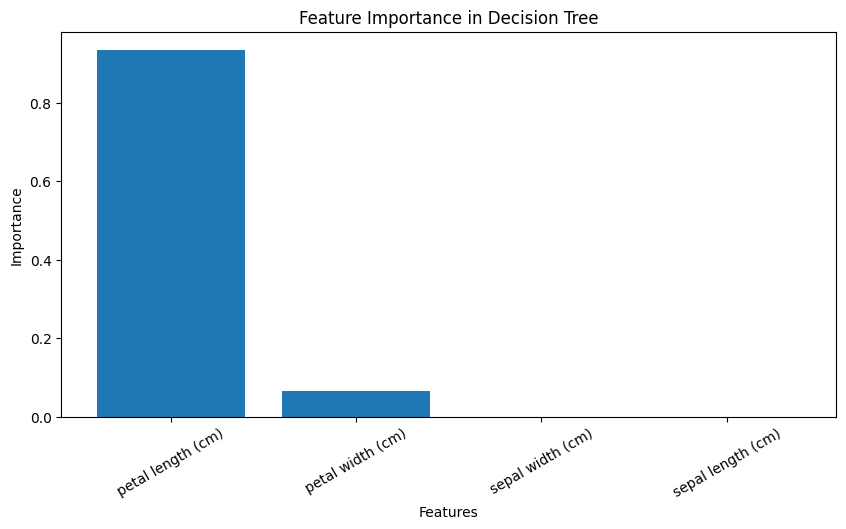

In [ ]:
# Create a bar chart for feature importance
plt.figure(figsize=(10, 5))

plt.bar(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

# Add labels and title
plt.xlabel("Features")
plt.ylabel("Importance")
plt.title("Feature Importance in Decision Tree")

# Rotate feature names for better readability
plt.xticks(rotation=30)

# Display the graph
plt.show()

# **Test with a New Input**

In [ ]:
# Create a new flower sample
# Values represent:
# sepal length, sepal width, petal length, petal width

new_sample = [[5.1, 3.5, 1.4, 0.2]]

# Predict the class of the new flower
prediction = model.predict(new_sample)

# Display the predicted class
print("Predicted Class:", iris.target_names[prediction[0]])

Predicted Class: setosa


# **Result**

The Decision Tree Classification model was successfully implemented using Python and Scikit-learn. The model was trained using the Gini impurity criterion, tested on unseen data, and evaluated using accuracy. The decision tree and feature importance were also visualized.

# **Conclusion**

A Decision Tree provides an easy-to-understand method for classification because its decision-making process can be represented as a tree structure. Gini impurity can be used to select suitable splits, with lower impurity indicating a better split according to the provided material.